## fxn/utils import

In [4]:
from jax import vmap
import jax
import time
import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import jax.numpy as jnp
import jax.random as jr
from jax import vmap, jit, value_and_grad

import optax
import time
import functools as ft
import matplotlib.pyplot as plt
import numpy as np
import time

In [5]:
print("\nconfiguring backend...")
jax.config.update("jax_platform_name", "cpu")


print("backend selected:\n", jax.default_backend())
print("active devices:\n", jax.devices())
print("--------------------\n")


configuring backend...
Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB

backend selected:
 cpu
active devices:
 [CpuDevice(id=0)]
--------------------



W0000 00:00:1776897376.496323 37567598 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1776897376.518696 37567598 service.cc:145] XLA service 0x13fb5f380 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776897376.518722 37567598 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1776897376.522062 37567598 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1776897376.522075 37567598 mps_client.cc:384] XLA backend will use up to 11452858368 bytes on device 0 for SimpleAllocator.


In [6]:

def activation_fn_load(act_func):
    if act_func == 'tanh':
        activation = jnp.tanh
    if act_func == 'relu':
        activation = jax.nn.relu
    if act_func == 'swish':
        activation = jax.nn.swish
    if act_func == 'sine':
        activation = jnp.sin
    if act_func == 'cosine':
        activation = jnp.cos
    if act_func == 'gelu':
        activation = jax.nn.gelu
    return activation

class DeepONet(eqx.Module):
   trunk: eqx.nn.MLP
   branch: eqx.nn.MLP
   
   def __init__(
         self, 
         TRUNK_INPUT_DIM , TRUNK_OUTPUT_DIM , TRUNK_WIDTH , TRUNK_DEPTH , TRUNK_ACT ,
         BRANCH_INPUT_DIM, BRANCH_OUTPUT_DIM, BRANCH_WIDTH, BRANCH_DEPTH, BRANCH_ACT, 
         *, key
   ):
      key, subkey_trunk, subkey_branch = jr.split(key, num=3)
      self.trunk  = eqx.nn.MLP(in_size=TRUNK_INPUT_DIM , out_size=TRUNK_OUTPUT_DIM , width_size=TRUNK_WIDTH , depth=TRUNK_DEPTH , activation=activation_fn_load(TRUNK_ACT) , key=subkey_trunk)
      self.branch = eqx.nn.MLP(in_size=BRANCH_INPUT_DIM, out_size=BRANCH_OUTPUT_DIM, width_size=BRANCH_WIDTH, depth=BRANCH_DEPTH, activation=activation_fn_load(BRANCH_ACT), key=subkey_branch)

   def __call__(self, f, x):
      trunk  = jnp.concatenate([self.trunk(x),jnp.ones((1,))])
      branch = self.branch(f)
      return jnp.dot(trunk, branch)

def create_DeepONet(*, key, HYPER_MODEL):
    TRUNK_INPUT_DIM   = HYPER_MODEL["TRUNK"]["input_dim"]
    TRUNK_OUTPUT_DIM  = HYPER_MODEL["TRUNK"]["output_dim"]
    TRUNK_WIDTH       = HYPER_MODEL["TRUNK"]["width"]
    TRUNK_DEPTH       = HYPER_MODEL["TRUNK"]["depth"]
    TRUNK_ACT         = HYPER_MODEL["TRUNK"]["act_func"]
    BRANCH_INPUT_DIM  = HYPER_MODEL["BRANCH"]["input_dim"]
    BRANCH_OUTPUT_DIM = HYPER_MODEL["BRANCH"]["output_dim"]
    BRANCH_WIDTH      = HYPER_MODEL["BRANCH"]["width"]
    BRANCH_DEPTH      = HYPER_MODEL["BRANCH"]["depth"]
    BRANCH_ACT        = HYPER_MODEL["BRANCH"]["act_func"]
    model = DeepONet(key=key, 
                     TRUNK_INPUT_DIM=TRUNK_INPUT_DIM, 
                     TRUNK_OUTPUT_DIM=TRUNK_OUTPUT_DIM, 
                     TRUNK_WIDTH=TRUNK_WIDTH, 
                     TRUNK_DEPTH=TRUNK_DEPTH, 
                     TRUNK_ACT=TRUNK_ACT,
                     BRANCH_INPUT_DIM=BRANCH_INPUT_DIM, 
                     BRANCH_OUTPUT_DIM=BRANCH_OUTPUT_DIM, 
                     BRANCH_WIDTH=BRANCH_WIDTH, 
                     BRANCH_DEPTH=BRANCH_DEPTH, 
                     BRANCH_ACT=BRANCH_ACT)
    return model

def load_DeepONet(filename):
    with open(filename, "rb") as f:
        hyperparams = json.loads(f.readline().decode())
        model = create_DeepONet(key=jr.PRNGKey(0), HYPER_MODEL=hyperparams)
        return eqx.tree_deserialise_leaves(f, model)


def create_FNN(*, key, input_dim, output_dim, width, depth, act_func):
    activation = activation_fn_load(act_func)
    return eqx.nn.MLP(in_size=input_dim, out_size=output_dim, width_size=width, depth=depth, activation=activation, key=key)

def save_MODEL(filename, hyperparams, model):
    with open(filename, "wb") as f:
        hyperparam_str = json.dumps(hyperparams)
        f.write((hyperparam_str + "\n").encode())
        eqx.tree_serialise_leaves(f, model)

def load_FNN(filename):
    with open(filename, "rb") as f:
        hyperparams = json.loads(f.readline().decode())
        model = create_FNN(key=jr.PRNGKey(0), **hyperparams)
        return eqx.tree_deserialise_leaves(f, model)

def create_OPTIMIZER(optim_hyperparams):
    LR0   = optim_hyperparams['LEARNING_RATE_INITIAL']
    if optim_hyperparams['LEARNING_RATE_SCHEDULER'] == 'exponential':
        STEP  = optim_hyperparams['LEARNING_RATE_STEP']
        DECAY = optim_hyperparams['LEARNING_RATE_DECAY']
        LEARNING_RATE = optax.schedules.exponential_decay(LR0, STEP, DECAY)
    else:
        LEARNING_RATE = LR0
    
    OPTIM_NAME = optim_hyperparams['NAME']
    print(f'Selected Optimizer is [ {OPTIM_NAME} ], Initial Learning Rate is {LR0:1.2e}')
    if optim_hyperparams['LEARNING_RATE_SCHEDULER'] == 'exponential':
        print(f'You are using [ exponential ] learning rate scheduler with rate: {DECAY:.2f} and step: {STEP}')
    else:
        print(f'You are using [ constant ] learning rate')
            
    if OPTIM_NAME == 'adabelief':
        optimizer = optax.adabelief(LEARNING_RATE)
    if OPTIM_NAME == 'adadelta':
        optimizer = optax.adadelta(LEARNING_RATE)
    if OPTIM_NAME == 'adan':
        optimizer = optax.adan(LEARNING_RATE)
    if OPTIM_NAME == 'adafactor':
        optimizer = optax.adafactor(LEARNING_RATE)
    if OPTIM_NAME == 'adagrad':
        optimizer = optax.adagrad(LEARNING_RATE) 
    if OPTIM_NAME == 'adam':
        optimizer = optax.adam(LEARNING_RATE) 
    if OPTIM_NAME == 'adamw':
        optimizer = optax.adamw(LEARNING_RATE) 
    if OPTIM_NAME == 'adamax':
        optimizer = optax.adamax(LEARNING_RATE) 
    if OPTIM_NAME == 'adamaxw':
        optimizer = optax.adamaxw(LEARNING_RATE) 
    if OPTIM_NAME == 'amsgrad':
        optimizer = optax.amsgrad(LEARNING_RATE) 
    if OPTIM_NAME == 'lion':
        optimizer = optax.lion(LEARNING_RATE) 
    if OPTIM_NAME == 'nadam':
        optimizer = optax.nadam(LEARNING_RATE)
    if OPTIM_NAME == 'nadamw':
        optimizer = optax.nadamw(LEARNING_RATE) 
    if OPTIM_NAME == 'novograd':
        optimizer = optax.novograd(LEARNING_RATE) 
    if OPTIM_NAME == 'polyak_sgd':
        optimizer = optax.polyak_sgd(LEARNING_RATE)
    if OPTIM_NAME == 'radam':
        optimizer = optax.radam(LEARNING_RATE) 
    if OPTIM_NAME == 'rmsprop':
        optimizer = optax.rmsprop(LEARNING_RATE)
    if OPTIM_NAME == 'sgd':
        optimizer = optax.sgd(LEARNING_RATE) 
    if OPTIM_NAME == 'sm3':
        optimizer = optax.sm3(LEARNING_RATE)
    if OPTIM_NAME == 'yogi':
        optimizer = optax.yogi(LEARNING_RATE) 
         
    return optimizer


def training_MODEL(model, custom_loss_fn, HYPER_OPTIM):
  
  MAXITER     = HYPER_OPTIM['MAXITER']
  PRINT_EVERY = HYPER_OPTIM['PRINT_EVERY']
  optimizer  = create_OPTIMIZER(HYPER_OPTIM)
  opt_state  = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

  @eqx.filter_value_and_grad
  def loss_fn(model):
    return custom_loss_fn(model)

  @eqx.filter_jit
  def make_step(model, opt_state):
    lvalue, grads = loss_fn(model)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return lvalue, model, opt_state

  log_loss  = []
  log_minloss = []
  print(25*'-' + 'TRAINING STARTS' + 25*'-')
  print(65*'-')
  start_time = time.time()
  for epoch in range(MAXITER):
      current_loss, model, opt_state = make_step(model, opt_state)
      log_loss.append(current_loss)
      if epoch == 0:
          log_minloss.append(current_loss)
          model_opt = model
      else:
          if current_loss < log_minloss[-1]:
            minloss = current_loss
            model_opt = model
          else:
            minloss = log_minloss[-1]
          log_minloss.append(minloss)
          
      if (epoch == 0) or (epoch % PRINT_EVERY == 0):
          end_time = time.time()
          if PRINT_EVERY >= 1000:
            print(f"Epoch {epoch//1000:3d}K: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
          else:
            print(f"Epoch {epoch:4d}: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
          start_time = time.time()

  current_loss, _ = loss_fn(model)
  log_loss.append(current_loss)        
  if current_loss < log_minloss[-1]:
    minloss = current_loss
    model_opt = model
  else:
    minloss = log_minloss[-1]
  log_minloss.append(minloss)
  end_time = time.time()
  if PRINT_EVERY >= 1000:
    print(f"Epoch {MAXITER//1000:3d}K: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
  else:
    print(f"Epoch {MAXITER:4d}: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
  
  
  if HYPER_OPTIM['LBFGS']['USE'] == 'on':
      params, static = eqx.partition(model_opt, eqx.is_array)
      optim = optax.lbfgs()
      opt_state = optim.init(params)
    
      @eqx.filter_jit
      def loss_fn_LBFGS(params):
        model = eqx.combine(params, static)
        return custom_loss_fn(model)

      @eqx.filter_jit
      def make_step_bfgs(params, opt_state):
        loss, grads = eqx.filter_value_and_grad(loss_fn_LBFGS)(params)

        updates, opt_state = optim.update(
                grads, 
                opt_state,
                params,
                value=loss,
                grad=grads,
                value_fn=loss_fn_LBFGS
            )

        params = eqx.apply_updates(params, updates)
        return loss, params, opt_state
    
      # Training Loop 
      MAXITER     = HYPER_OPTIM['LBFGS']['MAXITER']
      PRINT_EVERY = HYPER_OPTIM['LBFGS']['PRINT_EVERY']
      print(65*'-')
      print(21*'-' + '[LBFGS] TRAINING STARTS' + 21*'-')
      print(25*'-' + f' MAXITER= {MAXITER} ' + 25*'-')
      start_time  = time.time()
      for epoch in range(MAXITER):
        model = eqx.combine(params, static)
        current_loss, params, opt_state = make_step_bfgs(params, opt_state)
        log_loss.append(current_loss)
        if epoch == 0:
          log_minloss.append(current_loss)
          model_opt = model
        else:
          if current_loss < log_minloss[-1]:
            minloss = current_loss
            model_opt = model
          else:
            minloss = log_minloss[-1]
          log_minloss.append(minloss)
          
        if (epoch == 0) or (epoch % PRINT_EVERY == 0):
          end_time = time.time()
          if PRINT_EVERY >= 1000:
             print(f"[LBFGS] Ep {epoch//1000:3d}K: loss = {current_loss:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
          else:
             print(f"[LBFGS] Ep {epoch:3d}: loss = {current_loss:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
          start_time = time.time()
          
      model = eqx.combine(params, static)
      current_loss, _ = loss_fn(model)
      log_loss.append(current_loss)        
      if current_loss < log_minloss[-1]:
          minloss = current_loss
          model_opt = model
      else:
          minloss = log_minloss[-1]
          log_minloss.append(minloss)
      end_time = time.time()
      if PRINT_EVERY >= 1000:
          print(f"[LBFGS] Ep {MAXITER//1000:3d}K: loss = {current_loss:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
      else:
          print(f"[LBFGS] Ep{MAXITER:3d}: loss = {current_loss:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
    
  return model_opt, log_loss, log_minloss



def training_MODEL_RBA(model, custom_loss_fn, custom_loss_fn_LBFGS, HYPER_OPTIM, HYPER_RBA):
  
  MAXITER     = HYPER_OPTIM['MAXITER']
  PRINT_EVERY = HYPER_OPTIM['PRINT_EVERY']
  optimizer  = create_OPTIMIZER(HYPER_OPTIM)
  opt_state  = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

  RBA_lambda = HYPER_RBA['RBA_lambda']
  
#   @eqx.filter_value_and_grad
  @eqx.filter_jit
  def loss_fn(model,RBA_lambda):
    return custom_loss_fn(model,RBA_lambda)

  @eqx.filter_jit
  def make_step(model, opt_state, RBA_lambda):
    loss_fn_RBA = ft.partial(loss_fn, RBA_lambda=RBA_lambda)
    (_, (RBA_lambda,lvalue)), grads = eqx.filter_value_and_grad(loss_fn_RBA, has_aux=True)(model)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return lvalue, model, opt_state, RBA_lambda

  log_loss  = []
  log_minloss = []
  print(25*'-' + 'TRAINING STARTS' + 25*'-')
  print(65*'-')
  start_time = time.time()
  for epoch in range(MAXITER):
      current_loss, model, opt_state, RBA_lambda = make_step(model, opt_state, RBA_lambda)
      log_loss.append(current_loss)
      if epoch == 0:
          log_minloss.append(current_loss)
          model_opt = model
      else:
          if current_loss < log_minloss[-1]:
            minloss = current_loss
            model_opt = model
          else:
            minloss = log_minloss[-1]
          log_minloss.append(minloss)
          
      if (epoch == 0) or (epoch % PRINT_EVERY == 0):
          end_time = time.time()
          if PRINT_EVERY >= 1000:
            print(f"Epoch {epoch//1000:3d}K: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
          else:
            print(f"Epoch {epoch:4d}: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
          start_time = time.time()

  current_loss = loss_fn(model,RBA_lambda)[1][1]
  log_loss.append(current_loss)        
  if current_loss < log_minloss[-1]:
    minloss = current_loss
    model_opt = model
  else:
    minloss = log_minloss[-1]
  log_minloss.append(minloss)
  end_time = time.time()
  if PRINT_EVERY >= 1000:
    print(f"Epoch {MAXITER//1000:3d}K: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
  else:
    print(f"Epoch {MAXITER:4d}: loss = {current_loss:.4e}, minloss = {log_minloss[-1]:.4e}, Time: {end_time-start_time:.2f}s")
  
  
  if HYPER_OPTIM['LBFGS']['USE'] == 'on':
      params, static = eqx.partition(model_opt, eqx.is_array)
      optim = optax.lbfgs()
      opt_state = optim.init(params)
    
      @eqx.filter_jit
      def loss_fn_LBFGS(params):
        model = eqx.combine(params, static)
        return ft.partial(custom_loss_fn_LBFGS, RBA_lambda=RBA_lambda)(model)

      @eqx.filter_jit
      def make_step_bfgs(params, opt_state):
        loss, grads = eqx.filter_value_and_grad(loss_fn_LBFGS)(params)

        updates, opt_state = optim.update(
                grads, 
                opt_state,
                params,
                value=loss,
                grad=grads,
                value_fn=loss_fn_LBFGS
            )

        params = eqx.apply_updates(params, updates)
        return loss, params, opt_state
    
      # Training Loop 
      MAXITER     = HYPER_OPTIM['LBFGS']['MAXITER']
      PRINT_EVERY = HYPER_OPTIM['LBFGS']['PRINT_EVERY']
      print(65*'-')
      print(21*'-' + '[LBFGS] TRAINING STARTS' + 21*'-')
      print(25*'-' + f' MAXITER= {MAXITER} ' + 25*'-')
      start_time  = time.time()
      for epoch in range(MAXITER):
        model = eqx.combine(params, static)
        current_loss, params, opt_state = make_step_bfgs(params, opt_state)
        log_loss.append(current_loss)
        if epoch == 0:
          log_minloss.append(current_loss)
          model_opt = model
        else:
          if current_loss < log_minloss[-1]:
            minloss = current_loss
            model_opt = model
          else:
            minloss = log_minloss[-1]
          log_minloss.append(minloss)
          
        if (epoch == 0) or (epoch % PRINT_EVERY == 0):
          end_time = time.time()
          if PRINT_EVERY >= 1000:
             print(f"[LBFGS] Ep {epoch//1000:3d}K: loss = {loss_fn(model,RBA_lambda)[1][1]:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
          else:
             print(f"[LBFGS] Ep {epoch:3d}: loss = {loss_fn(model,RBA_lambda)[1][1]:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
          start_time = time.time()
          
      model = eqx.combine(params, static)
      current_loss = loss_fn(model,RBA_lambda)[1][1]
      log_loss.append(current_loss)        
      if current_loss < log_minloss[-1]:
          minloss = current_loss
          model_opt = model
      else:
          minloss = log_minloss[-1]
          log_minloss.append(minloss)
      end_time = time.time()
      if PRINT_EVERY >= 1000:
          print(f"[LBFGS] Ep {MAXITER//1000:3d}K: loss = {loss_fn(model,RBA_lambda)[1][1]:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
      else:
          print(f"[LBFGS] Ep{MAXITER:3d}: loss = {loss_fn(model,RBA_lambda)[1][1]:.2e}, minloss = {log_minloss[-1]:.2e}, Time: {end_time-start_time:.2f}s")
    
  return model_opt, log_loss, log_minloss

## load data

In [7]:
test_data = jnp.load("hw4_burgers_train_data.npz")
train_data = jnp.load("hw4_burgers_train_data.npz")


test_xt, test_u, test_params = test_data["xt_grid"], test_data["u_sol"], test_data["params"]
train_xt, train_u, train_params = train_data["xt_grid"], train_data["u_sol"], train_data["params"]

t_grid = jnp.unique(train_xt[:, 0])
x_grid = jnp.unique(train_xt[:, 1])

FileNotFoundError: [Errno 2] No such file or directory: 'hw4_burgers_train_data.npz'

## deeponet definition


In [ ]:
SEED = 77

# per assignment
BRANCH_INPUT_DIM  = 2
BRANCH_WIDTH      = 100
BRANCH_DEPTH      = 4
BRANCH_ACTIVATION = 'tanh'

TRUNK_INPUT_DIM   = 2
TRUNK_WIDTH       = 16
TRUNK_DEPTH       = 4
TRUNK_ACTIVATION  = 'gelu'

DEEPONET_WIDTH    = 4
# sine, cosine, relu, tanh, gelu, swish


LEARNING_RATE = 1e-3
OPTIMIZER_NAME = 'adam'
# adabelief, adadelta, adan, adafactor, adagrad, adam, adamw,
# adamax, adamaxw, amsgrad, lion, nadam, nadamw, novograd, radam,
# rmsprop, sgd, sm3, yogi, polyak_sgd
MAXITER = 40_000
PRINT_EVERY = 1_000

LR_SCHEDULER = 'constant' # exponential or constant
LR_DECAY = 0.95
LR_STEP  = 3000

LBFGS_USE = 'off'
LBFGS_MAXITER = 10_000
LBFGS_PRINT_EVERY = 1_000
if LBFGS_USE != 'on':
    LBFGS_MAXITER = 0
    LBFGS_PRINT_EVERY = 0

In [ ]:
HYPER_MODEL = {"TRUNK": {"input_dim": TRUNK_INPUT_DIM, 
               "output_dim": DEEPONET_WIDTH, 
               "width": TRUNK_WIDTH,
               "depth": TRUNK_DEPTH-1, 
               "act_func": TRUNK_ACTIVATION},
               "BRANCH": {"input_dim": BRANCH_INPUT_DIM, 
               "output_dim": DEEPONET_WIDTH+1, 
               "width": BRANCH_WIDTH,
               "depth": BRANCH_DEPTH-1, 
               "act_func": BRANCH_ACTIVATION}
            }

HYPER_OPTIM = {"MAXITER": MAXITER, 
               "NAME": OPTIMIZER_NAME, 
               "LEARNING_RATE_SCHEDULER": LR_SCHEDULER, 
               "LEARNING_RATE_INITIAL": LEARNING_RATE, 
               "LEARNING_RATE_DECAY": LR_DECAY, 
               "LEARNING_RATE_STEP": LR_STEP, 
               "PRINT_EVERY": PRINT_EVERY,
               "LBFGS": {"USE": LBFGS_USE, "MAXITER": LBFGS_MAXITER, "PRINT_EVERY": LBFGS_PRINT_EVERY}
               }

In [ ]:
key = jr.PRNGKey(SEED)
key, subkey_model_trunk, subkey_model_A, subkey_model_branch, subkey_w, subkey_w_test = jr.split(key, num=6)

In [ ]:
model_trunk = create_FNN(key=subkey_model_trunk, **HYPER_MODEL["TRUNK"])

In [ ]:
# model_A     = jr.normal(key=subkey_model_A,shape=(DEEPONET_WIDTH+1, num_op_data))
model_A = jnp.zeros((DEEPONET_WIDTH + 1, train_u.shape[0]))  # (p+1, N_train)
print(model_A.shape)
model       = model_trunk, model_A

(5, 25)


## loss fn and training

### trunk network

In [ ]:
def loss_fn(model):
    model_trunk, model_A = model
    residual = (jnp.concatenate([vmap(lambda x: model_trunk(x))(train_xt), jnp.ones([train_xt.shape[0],1])],axis=1) @ model_A).T - train_u
    return jnp.mean(residual**2)

In [ ]:
start_time = time.time()
model, log_loss, log_minloss = training_MODEL(model, loss_fn, HYPER_OPTIM)
end_time = time.time()

Selected Optimizer is [ adam ], Initial Learning Rate is 1.00e-03
You are using [ constant ] learning rate
-------------------------TRAINING STARTS-------------------------
-----------------------------------------------------------------
Epoch   0K: loss = 1.5688e-01, minloss = 1.5688e-01, Time: 0.28s
Epoch   1K: loss = 3.9804e-04, minloss = 3.9804e-04, Time: 8.70s
Epoch   2K: loss = 9.5297e-05, minloss = 9.5297e-05, Time: 7.98s
Epoch   3K: loss = 5.5546e-05, minloss = 5.5546e-05, Time: 7.89s
Epoch   4K: loss = 3.6878e-05, minloss = 3.6878e-05, Time: 8.44s
Epoch   5K: loss = 2.6274e-05, minloss = 2.6274e-05, Time: 7.42s
Epoch   6K: loss = 2.0356e-05, minloss = 2.0356e-05, Time: 7.93s
Epoch   7K: loss = 1.6480e-05, minloss = 1.6479e-05, Time: 7.43s
Epoch   8K: loss = 1.3875e-05, minloss = 1.3875e-05, Time: 7.41s
Epoch   9K: loss = 1.2082e-05, minloss = 1.2082e-05, Time: 7.18s
Epoch  10K: loss = 1.0663e-05, minloss = 1.0663e-05, Time: 7.31s
Epoch  11K: loss = 9.2158e-06, minloss = 9.122

In [ ]:
model_trunk, model_A = model
T_MAT = jnp.concatenate([vmap(lambda x: model_trunk(x))(train_xt), jnp.ones([train_xt.shape[0],1])],axis=1)
import scipy.linalg as la

Q, R  = la.qr(np.array(T_MAT), mode='economic')                 # Q:(N_xt, p+1), R:(p+1, p+1)
U_true = np.array(train_u).T                                     # (N_xt, N_train)
lsq_A  = la.lstsq(np.array(T_MAT), U_true)[0]        # (p+1, N_train)
branch_output_data = R @ lsq_A      


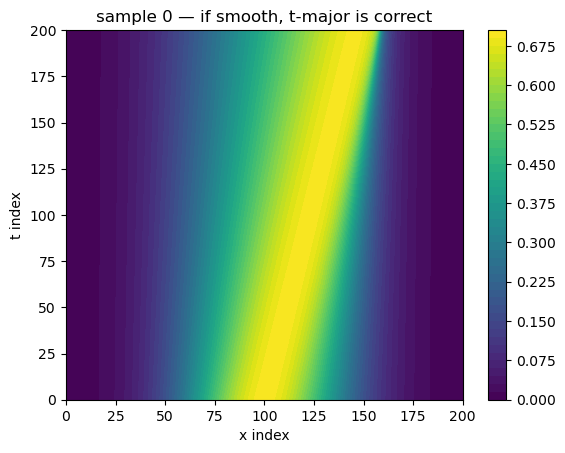

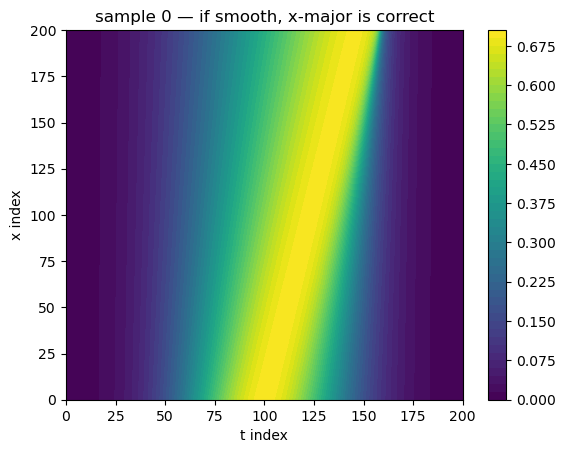

In [ ]:
import matplotlib.pyplot as plt

n = len(x_grid)  # or len(t_grid), whichever you suspect is fast

sample = train_u[0].reshape(len(t_grid), len(x_grid))  # assume t-major
plt.figure()
plt.contourf(sample, levels=50, cmap='viridis')
plt.xlabel('x index')
plt.ylabel('t index')
plt.colorbar()
plt.title('sample 0 — if smooth, t-major is correct')
plt.show()

sample2 = train_u[0].reshape(len(x_grid), len(t_grid))  # assume x-major
plt.figure()
plt.contourf(sample2, levels=50, cmap='viridis')
plt.xlabel('t index')
plt.ylabel('x index')
plt.colorbar()
plt.title('sample 0 — if smooth, x-major is correct')
plt.show()

### branch network

In [ ]:
model_branch= create_FNN(key=subkey_model_branch, **HYPER_MODEL["BRANCH"])

LEARNING_RATE = 1e-3
OPTIMIZER_NAME = 'adam'
# adabelief, adadelta, adan, adafactor, adagrad, adam, adamw,
# adamax, adamaxw, amsgrad, lion, nadam, nadamw, novograd, radam,
# rmsprop, sgd, sm3, yogi, polyak_sgd
MAXITER = 150_000
PRINT_EVERY = 1_000

LR_SCHEDULER = 'constant' # exponential or constant
LR_DECAY = 0.90
LR_STEP  = 10_000

LBFGS_USE = 'off'
LBFGS_MAXITER = 10_000
LBFGS_PRINT_EVERY = 1_00
if LBFGS_USE != 'on':
    LBFGS_MAXITER = 0
    LBFGS_PRINT_EVERY = 0
    
HYPER_OPTIM_Branch = {"MAXITER": MAXITER, 
               "NAME": OPTIMIZER_NAME, 
               "LEARNING_RATE_SCHEDULER": LR_SCHEDULER, 
               "LEARNING_RATE_INITIAL": LEARNING_RATE, 
               "LEARNING_RATE_DECAY": LR_DECAY, 
               "LEARNING_RATE_STEP": LR_STEP, 
               "PRINT_EVERY": PRINT_EVERY,
               "LBFGS": {"USE": LBFGS_USE, "MAXITER": LBFGS_MAXITER, "PRINT_EVERY": LBFGS_PRINT_EVERY}
               }


In [ ]:
def branch_loss_fn(model):
    residual = vmap(model)(train_params).T - branch_output_data
    return jnp.mean((residual)**2)

start_time = time.time()
model_branch, log_loss_branch, log_minloss_branch = training_MODEL(model_branch, branch_loss_fn, HYPER_OPTIM_Branch)
end_time = time.time()

Selected Optimizer is [ adam ], Initial Learning Rate is 1.00e-03
You are using [ constant ] learning rate
-------------------------TRAINING STARTS-------------------------
-----------------------------------------------------------------
Epoch   0K: loss = 1.2698e+03, minloss = 1.2698e+03, Time: 0.14s
Epoch   1K: loss = 1.9894e+01, minloss = 1.9894e+01, Time: 0.57s
Epoch   2K: loss = 5.2648e+00, minloss = 5.2648e+00, Time: 0.58s
Epoch   3K: loss = 5.2630e+00, minloss = 5.2630e+00, Time: 0.57s
Epoch   4K: loss = 5.2630e+00, minloss = 5.2630e+00, Time: 0.55s
Epoch   5K: loss = 5.2630e+00, minloss = 5.2630e+00, Time: 0.56s
Epoch   6K: loss = 5.2630e+00, minloss = 5.2630e+00, Time: 0.62s
Epoch   7K: loss = 5.2630e+00, minloss = 5.2630e+00, Time: 0.56s
Epoch   8K: loss = 5.2629e+00, minloss = 5.2629e+00, Time: 0.55s
Epoch   9K: loss = 3.3383e-01, minloss = 3.3383e-01, Time: 0.56s
Epoch  10K: loss = 4.5964e-02, minloss = 2.2980e-03, Time: 0.56s
Epoch  11K: loss = 1.0908e-03, minloss = 1.090

In [ ]:
T_MAT = jnp.concatenate([vmap(lambda x: model_trunk(x))(train_xt), jnp.ones([train_xt.shape[0],1])],axis=1)
Q_tt = la.lstsq(R.T, T_MAT.T)[0].T
NN_pred_final = (Q_tt @ (vmap(model_branch)(jnp.atleast_1d(train_params)).T)).T

(25, 40401)
Avg. Relative L2 error     : 3.7829e-03


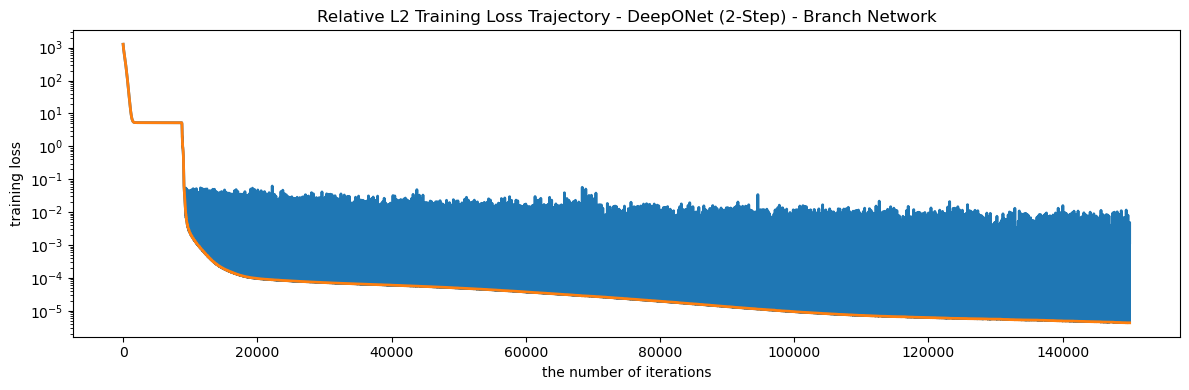

In [ ]:

print(NN_pred_final.shape)
rel_l2_error = jnp.sqrt(jnp.sum((test_u - NN_pred_final)**2,axis=1) / jnp.sum(test_u**2,axis=1))
print(f"Avg. Relative L2 error     : {jnp.mean(rel_l2_error):.4e}")



plt.figure(figsize = (12,4))
plt.semilogy(log_loss_branch, linewidth = 2)
plt.semilogy(log_minloss_branch, linewidth =2)
plt.xlabel('the number of iterations')
plt.ylabel('training loss')
plt.title("Relative L2 Training Loss Trajectory - DeepONet (2-Step) - Branch Network")
plt.tight_layout()
# plt.suptitle(title_str + '\n')
plt.savefig("deeponet_2step_training_branch.png")
plt.show()

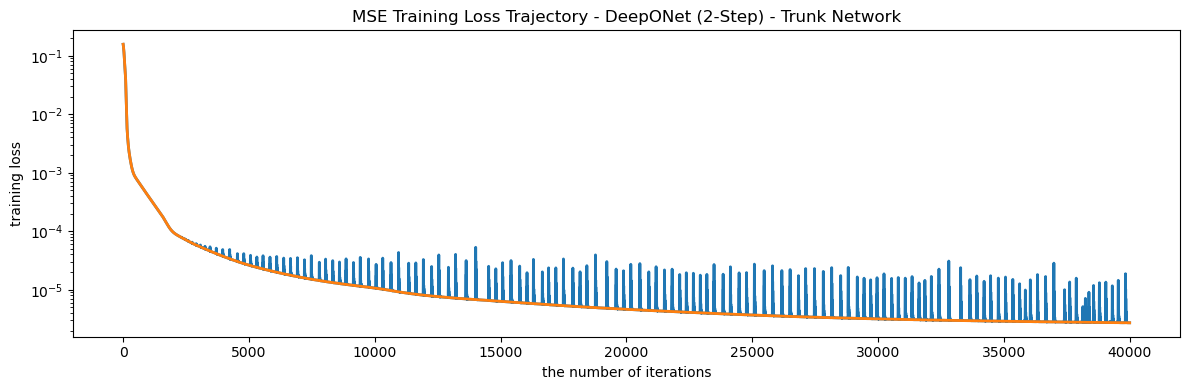

In [ ]:

# print(NN_pred_final.shape)
# rel_l2_error = jnp.sqrt(jnp.sum((test_u - NN_pred_final)**2,axis=1) / jnp.sum(test_u**2,axis=1))
# print(f"Avg. MSE error     : {jnp.mean(rel_l2_error):.4e}")



plt.figure(figsize = (12,4))
plt.semilogy(log_loss, linewidth = 2)
plt.semilogy(log_minloss, linewidth =2)
plt.xlabel('the number of iterations')
plt.ylabel('training loss')
plt.title("MSE Training Loss Trajectory - DeepONet (2-Step) - Trunk Network")
plt.tight_layout()
# plt.suptitle(title_str + '\n')
plt.savefig("deeponet_2step_training.png")
plt.show()

In [ ]:
np.savez('orth_loss_hist.npz', log_loss, log_minloss, log_loss_branch, log_minloss_branch, labels = ['log_loss_orth', 'log_minloss_orth', 'log_loss_branch_orth', 'log_minloss_branch_orth'])

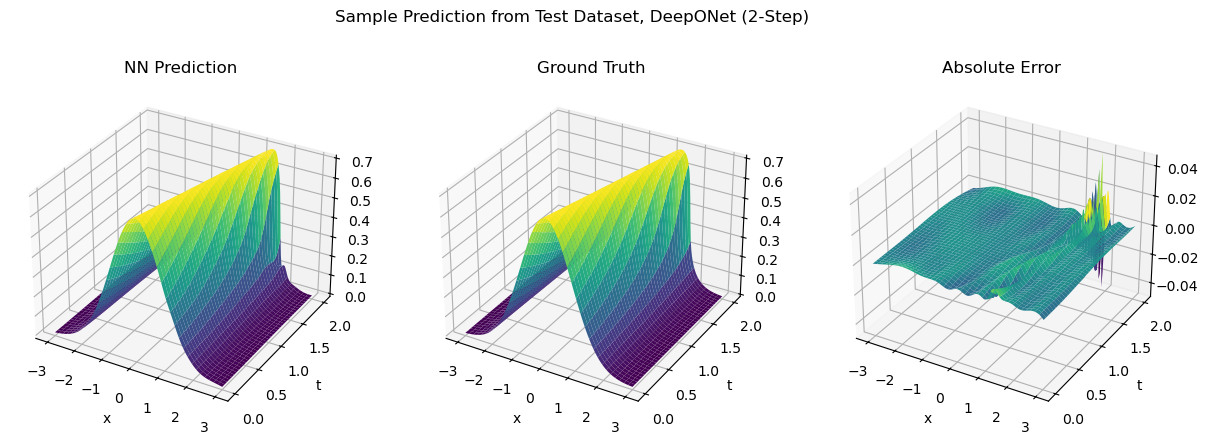

In [ ]:
NN_pred_final = (Q_tt @ (vmap(model_branch)(jnp.atleast_1d(test_params)).T)).T


x = train_xt[:, 0].reshape(201, 201)
t = train_xt[:, 1].reshape(201, 201)

pred = NN_pred_final[0].reshape(201, 201)
truth = train_u[0].reshape(201, 201)

#fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw=dict(projection='3d'))


im0 = axes[0].plot_surface(x, t, pred, cmap="viridis")
axes[0].set_title("NN Prediction")
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")
#axes[0].invert_yaxis()
#fig.colorbar(im0, ax=axes[0], fraction=0.02)

im1 = axes[1].plot_surface(x, t, truth, cmap="viridis")
axes[1].set_title("Ground Truth")
axes[1].set_xlabel("x")
axes[1].set_ylabel("t")


im1 = axes[2].plot_surface(x, t, pred - truth, cmap="viridis")
axes[2].set_title("Absolute Error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("t")
#fig.colorbar(im1, ax=axes[1], fraction=0.02)
plt.suptitle("Sample Prediction from Test Dataset, DeepONet (2-Step)")
plt.savefig("deeponet_2step_prediction.png", dpi=300)
plt.show()


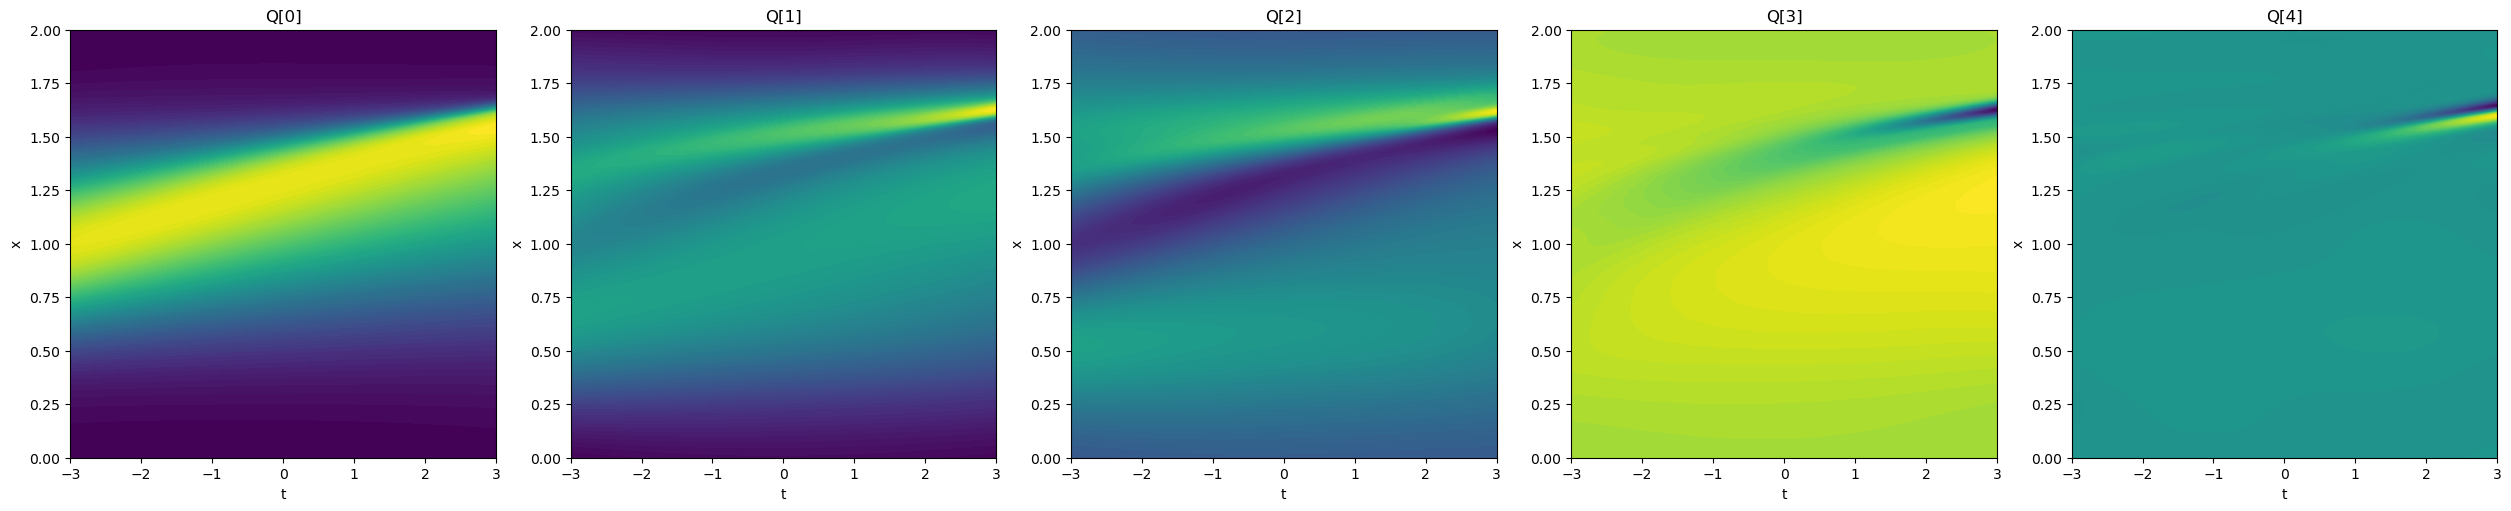

In [ ]:
num_bases = 5
ncols = 5
nrows = int(np.ceil(num_bases / ncols))
T, X  = np.meshgrid(t_grid, x_grid, indexing="ij")

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)
axes = axes.flatten()

for k, ax in enumerate(axes):
    if k < num_bases:
        b = Q[:,k].reshape(201,201)
        im  = ax.contourf(T, X, b, levels=100, cmap='viridis')
        ax.set_title(f"Q[{k}]")
        ax.set_xlabel("t")
        ax.set_ylabel("x")
    else:
        ax.axis("off")

In [ ]:
# loaded_model = load_DeepONet('DeepONet_Diff.eqx')

## add td qr to bases here

In [ ]:
# T_MAT_3d = T_MAT.reshape(len(t_grid), len(x_grid), -1)  # (X, T, K+1)

# ## ADDING
# T_MAT_3d = T_MAT_3d.transpose(1, 0, 2)  # (T, X, K+1)

# data is X major
T_MAT_3d = T_MAT.reshape(len(x_grid), len(t_grid), -1).transpose(1, 0, 2)  # (T, X, K+1)

#U_3d = np.array(train_u).reshape(train_u.shape[0], len(t_grid), len(x_grid)).transpose(1, 2, 0)  # (T, X, N)

U_3d = np.array(train_u).reshape(train_u.shape[0], len(x_grid), len(t_grid)).transpose(2, 1, 0)  # (T, X, N)

Q_ref, _ = la.qr(np.mean(T_MAT_3d, axis=1), mode='economic')  # (X, K+1)

Q_sign = None
R_sign = None


for i in range(len(t_grid)):
    Q, R = la.qr(np.array(T_MAT_3d[i, :, :]), mode='economic')  # QR of (X, K+1)
    
    if i == 0:
        Q_sign = Q[np.newaxis]
        R_sign = R[np.newaxis]
    else:
        for j in range(Q.shape[1]):
            overlap = np.dot(Q_sign[-1, :, j], Q[:, j])
            sign = np.sign(overlap) if np.abs(overlap) > 1e-10 else 1.0
            Q[:, j] *= sign
            R[j, :] *= sign
        Q_sign = np.concatenate([Q_sign, Q[np.newaxis]], axis=0)
        R_sign = np.concatenate([R_sign, R[np.newaxis]], axis=0)

In [ ]:
# lsq_A per time step: solve T_MAT_3d[t] @ A[t] = U_true for each t

#RA_target = np.zeros((len(t_grid), Q_sign.shape[2], train_u.shape[0]))
RA_target = np.random.randn(len(t_grid), Q_sign.shape[2], train_u.shape[0]) * 1e-3
for i in range(len(t_grid)):
    A_t = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]  # (K+1, N)
    RA_target[i] = R_sign[i] @ A_t

RA_target = jnp.array(RA_target)

In [ ]:
# reconstruct: Q_sign (T, X, K+1) @ R_sign (T, K+1, K+1) @ A_t should give U_3d
recon = np.einsum("txk,tkj->txj", Q_sign, R_sign) 
T_MAT_check = T_MAT_3d  # (T, X, K+1)
print("QR reconstruction error:", np.max(np.abs(recon - T_MAT_check)))

# also check that Q_sign @ R_sign @ A recovers U
A_check = np.zeros((len(t_grid), Q_sign.shape[2], train_u.shape[0]))
for i in range(len(t_grid)):
    A_check[i] = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]

recon_U = np.einsum("txk,tkn->txn", Q_sign, R_sign @ A_check if False else 
                    np.array([R_sign[i] @ A_check[i] for i in range(len(t_grid))]))
print("U reconstruction error:", np.max(np.abs(recon_U - U_3d)))

QR reconstruction error: 1.41859055e-05
U reconstruction error: 0.040790201750201316


In [ ]:
# check lstsq residual at a single time step
i = 0
A_t = la.lstsq(np.array(T_MAT_3d[i, :, :]), U_3d[i])[0]  # (K+1, N)
recon_slice = T_MAT_3d[i, :, :] @ A_t  # (X, N)
print("lstsq residual at t=0:", np.max(np.abs(recon_slice - U_3d[i])))

# check that R @ A recovers Q^T @ U
QTA = Q_sign[i].T @ U_3d[i]  # (K+1, N)
RA  = R_sign[i] @ A_t         # (K+1, N)
print("RA vs Q^T U error:", np.max(np.abs(RA - QTA)))

lstsq residual at t=0: 3.204588e-05
RA vs Q^T U error: 3.630143849409073e-08


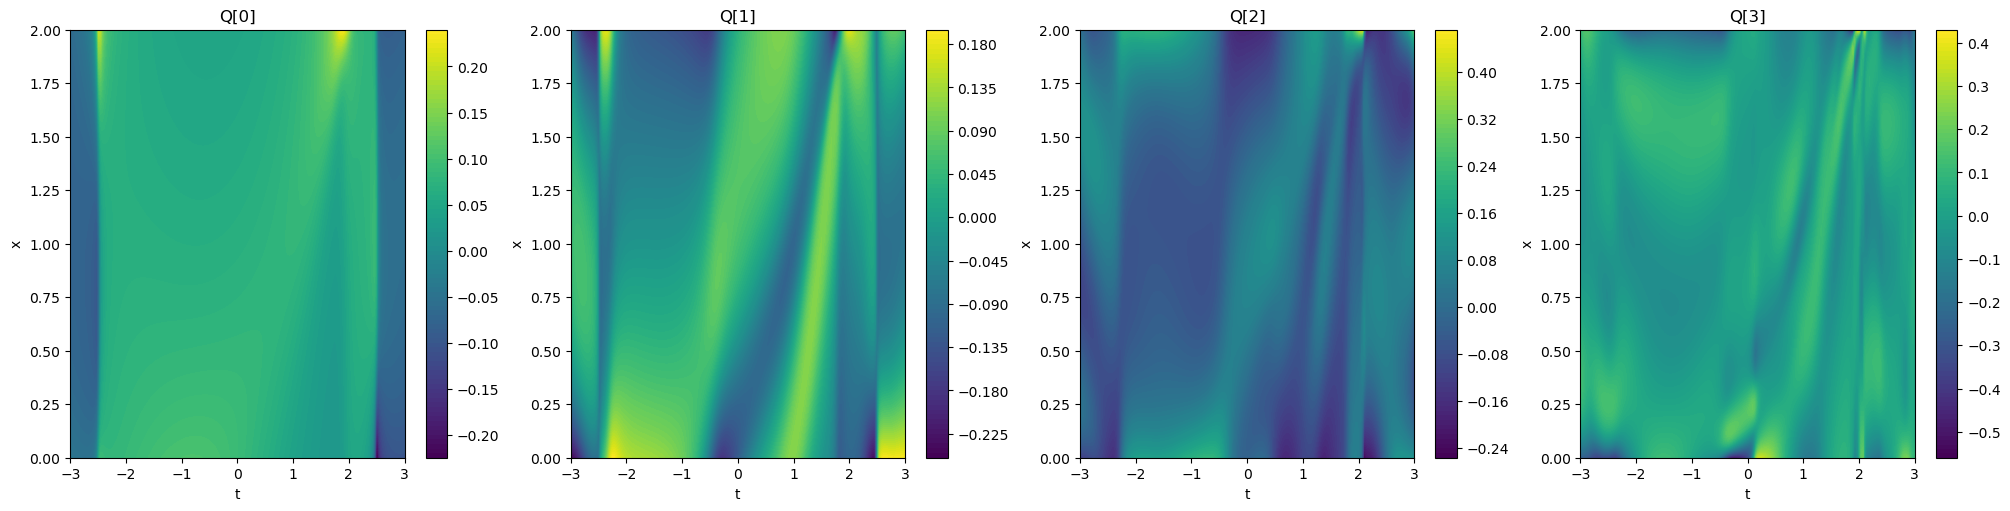

: 

In [ ]:
num_bases = 4
ncols = 4
nrows = int(np.ceil(num_bases / ncols))
T, X  = np.meshgrid(t_grid, x_grid, indexing="ij")

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), constrained_layout=True)
axes = axes.flatten()

for k, ax in enumerate(axes):
    if k < num_bases:
        Q_k = Q_sign[:, :, k]
        im  = ax.contourf(T, X, Q_k, levels=100, cmap='viridis')
        ax.set_title(f"Q[{k}]")
        ax.set_xlabel("t")
        ax.set_ylabel("x")
        fig.colorbar(im, ax=ax)
    else:
        ax.axis("off")

In [ ]:
recon_U = Q @ branch_output_data
print("U reconstruction error:", np.max(np.abs(recon_U - U_true)))

NameError: name 'Q' is not defined